# Compulsory Assignment 3: Semantic Segmentation With U-net

Mohamad Mohannad Al Kawadri



## Introduction
Chest X-ray(CXR) images are important in medical imaging because it helps focus analysis on the lung region, making disease detection (eg: pneumonia, COVID-19) more accurate and reliable. The purpose is to create clear lung masks that isolate the lungs from surrounding anatomy.

Lung segmentation is the process of separating lung regions from the rest of a chest X-ray. In this assignment, you are provided with CXR images and corresponding binary masks, where pixel values of 0 represent non-lung areas and 1 represents lung tissue. Your task is to focuse on semantic segmentation using a U-Net–style architecture. You will segment lung regions from chest X-ray images.




## The dataset we have been given

We have gotten 200 images of chest X-ray in grayscale, and 200 corresponding mask images that have been segmented. These are binary mask images, where 1 = lung region, and 0 = background region.

## Data Organization and Pairing

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys
sys.path.append("/content/drive/MyDrive/Colab Notebooks/CA3")

In [3]:
%pip install scikit-learn
%pip install tensorflow
%pip install matplotlib
%pip install numpy
%pip install pandas

In [3]:
import utilities as ut
import os, glob, random

import warnings
warnings.filterwarnings("ignore")

In [4]:
DATA_ROOT = r"/content/drive/MyDrive/Colab Notebooks/CA3/Images"
IMG_DIR = os.path.join(DATA_ROOT, "CXR_png")
MSK_DIR = os.path.join(DATA_ROOT, "masks")

pairs, missing = ut.build_pairs(IMG_DIR, MSK_DIR)
ut.report_pairs(pairs, missing)

Total images: 200
Matched pairs: 200
Missing masks: 0


Seems that there are no missing masks in the dataset.

#### Looking into the dataset images

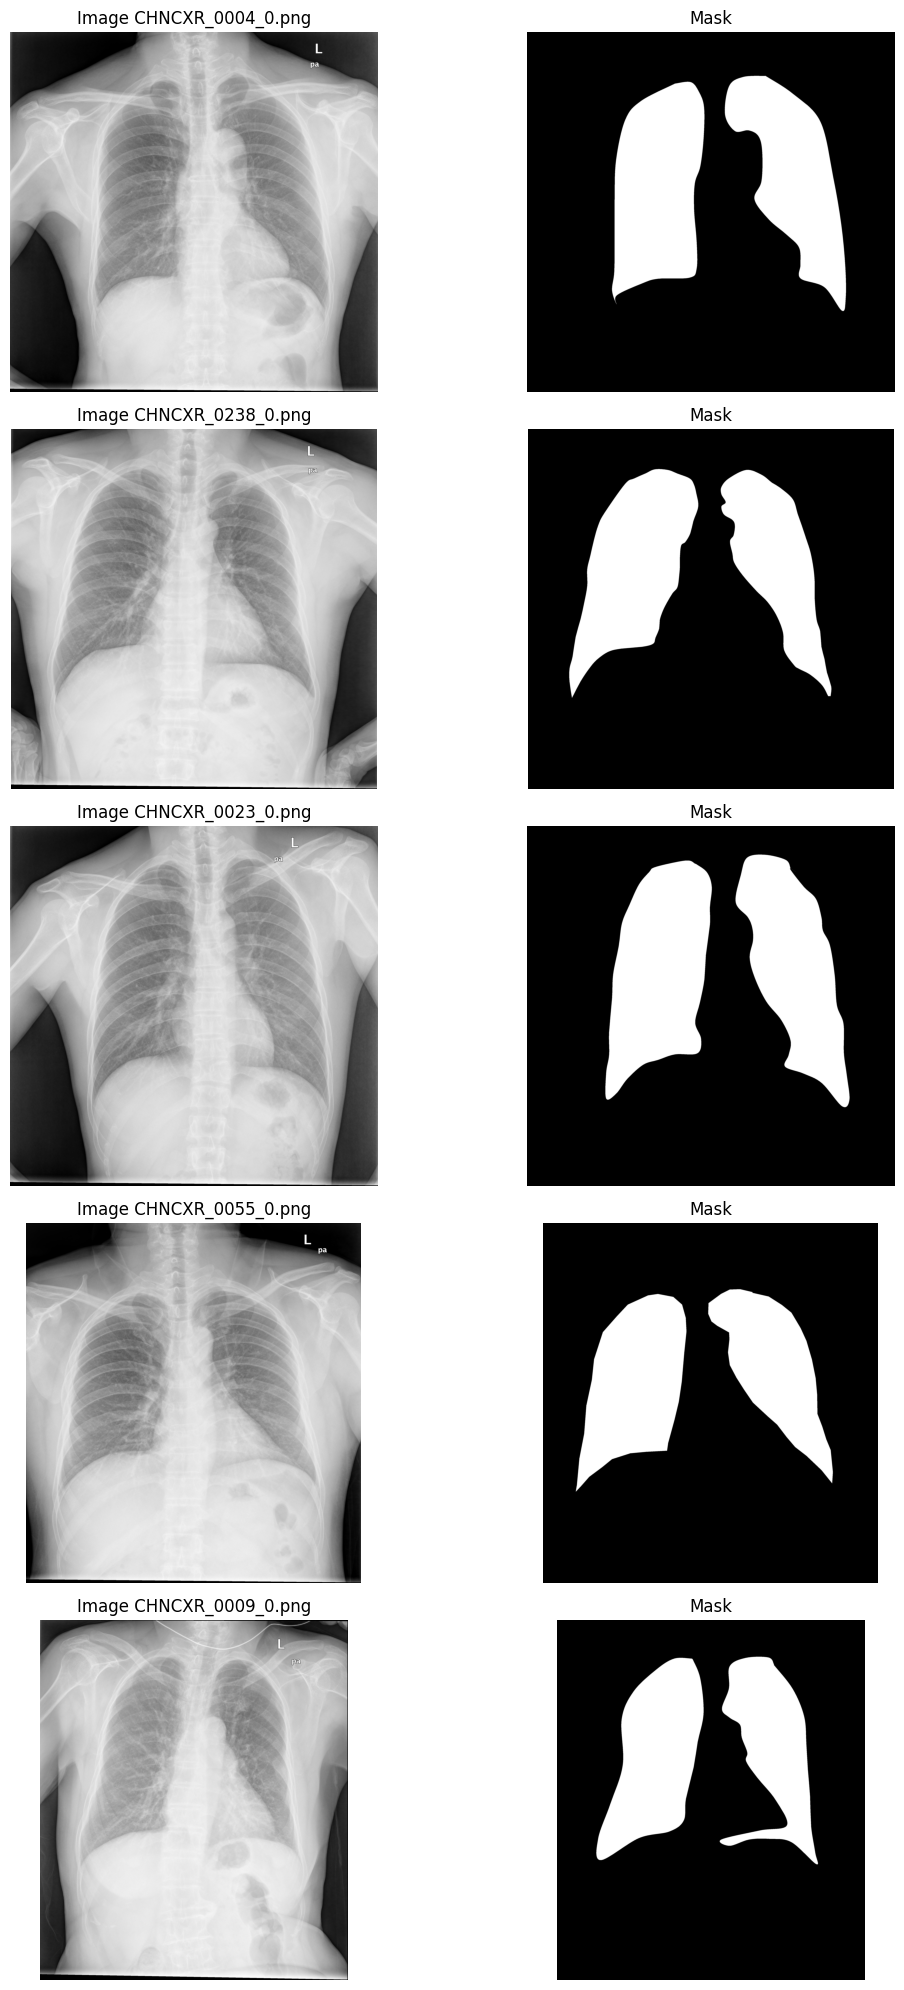

In [5]:
ut.peek_pairs(pairs, n_show=5)

#### Splitting the dataset into train, val and test

And visualizing the distribution

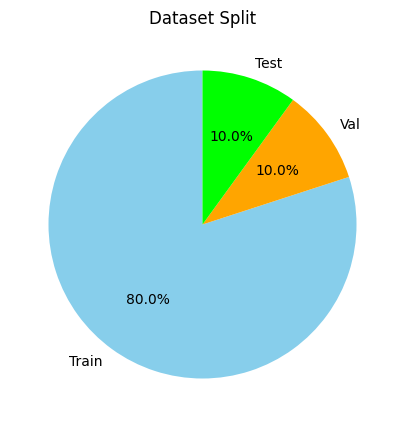

In [6]:
train, val, test = ut.split_dataset(pairs, seed=42)
ut.plot_split_distribution(train, val, test)

In [7]:
# Build datasets
train_ds = ut.make_dataset(train, augment_data=False)   # no augmentation
val_ds   = ut.make_dataset(val, augment_data=False)
test_ds = ut.make_dataset(test, augment_data=False)
train_aug_ds = ut.make_dataset(train, augment_data=True)

Alright, it seems that a lot of things happens under the hood when preparing the data for U-net. After some digging in utilities.py, we see that:

make_dataset() function calls load_pair.
This load_pair() function calls read_image() and read_mask(), and here the important preprocessing happens:
* Opens each file and resize them into fixed size (512x512)
* Convets them to tensors
* Normalize to [0,1]
* For masks, binarize them to class 0 and 1

And then back in make_dataset() function feeds the data in small batches, 4 in this case. Shuffles the data. This should then result a batchwise dataset, where each batch must be a tensor. Example for one image batch should have the dimensions [4, 512, 512, 3]. Here the length of first axis is 4, since there are 4 images per batch. The second and third axis lenght is 512, since these are the dimension of the image itself, and the length of last axis is 3, since there are 3 colour channles. For masks, its 1, since its in grayscale.


In [8]:
print("Pairs available:")
print("  Train set:", len(train), "pairs")
print("  Val set  :", len(val), "pairs")
print("  Test set :", len(test), "pairs")

Pairs available:
  Train set: 160 pairs
  Val set  : 20 pairs
  Test set : 20 pairs


In [9]:
for imgs, msks in train_ds.take(1):
    print("Before augmentation - images:", imgs.shape, "masks:", msks.shape)

# Inspect shapes after augmentation
for imgs, msks in train_aug_ds.take(1):
    print("After augmentation - images:", imgs.shape, "masks:", msks.shape)


Before augmentation - images: (4, 512, 512, 3) masks: (4, 512, 512, 1)
After augmentation - images: (4, 512, 512, 3) masks: (4, 512, 512, 1)


Here we got the dimensions of the tensors as expected!

## Model Implementation

In [10]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Conv2DTranspose, concatenate
from tensorflow.keras.models import Model

def conv2d_block(input_tensor, n_filters, kernel_size = 3, batchnorm = True):
    """Function to add 2 convolutional layers with the parameters passed to it"""
    # first layer
    x = Conv2D(filters = n_filters, kernel_size = (kernel_size, kernel_size),\
              kernel_initializer = 'he_normal', padding = 'same')(input_tensor)
    if batchnorm:
        x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # second layer
    x = Conv2D(filters = n_filters, kernel_size = (kernel_size, kernel_size),\
              kernel_initializer = 'he_normal', padding = 'same')(x)
    if batchnorm:
        x = BatchNormalization()(x)
    x = Activation('relu')(x)

    return x


In [11]:
def get_unet(input_img, n_filters=16, dropout=0.1, batchnorm=True, n_classes=1):
    # --- encoder ---
    c1 = conv2d_block(input_img, n_filters*1, 3, batchnorm); p1 = MaxPooling2D(2)(c1); p1 = Dropout(dropout)(p1)
    c2 = conv2d_block(p1,      n_filters*2, 3, batchnorm); p2 = MaxPooling2D(2)(c2); p2 = Dropout(dropout)(p2)
    c3 = conv2d_block(p2,      n_filters*4, 3, batchnorm); p3 = MaxPooling2D(2)(c3); p3 = Dropout(dropout)(p3)
    c4 = conv2d_block(p3,      n_filters*8, 3, batchnorm); p4 = MaxPooling2D(2)(c4); p4 = Dropout(dropout)(p4)
    c5 = conv2d_block(p4,      n_filters*16,3, batchnorm)

    # --- decoder ---
    u6 = Conv2DTranspose(n_filters*8, 3, strides=2, padding='same')(c5); u6 = concatenate([u6, c4]); u6 = Dropout(dropout)(u6)
    c6 = conv2d_block(u6, n_filters*8, 3, batchnorm)
    u7 = Conv2DTranspose(n_filters*4, 3, strides=2, padding='same')(c6); u7 = concatenate([u7, c3]); u7 = Dropout(dropout)(u7)
    c7 = conv2d_block(u7, n_filters*4, 3, batchnorm)
    u8 = Conv2DTranspose(n_filters*2, 3, strides=2, padding='same')(c7); u8 = concatenate([u8, c2]); u8 = Dropout(dropout)(u8)
    c8 = conv2d_block(u8, n_filters*2, 3, batchnorm)
    u9 = Conv2DTranspose(n_filters*1, 3, strides=2, padding='same')(c8); u9 = concatenate([u9, c1]); u9 = Dropout(dropout)(u9)
    c9 = conv2d_block(u9, n_filters*1, 3, batchnorm)

    # --- head ---
    if n_classes == 1:
        outputs = Conv2D(1, (1,1), activation='sigmoid')(c9)   # binary
    else:
        outputs = Conv2D(n_classes, (1,1), activation='softmax')(c9)  # multi-class

    return Model(inputs=[input_img], outputs=[outputs])

In [12]:
input_img = Input(shape=(512, 512, 3))
model_unet = get_unet(input_img, n_filters = 16, dropout = 0.1, batchnorm = True, n_classes = 1)
model_unet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │      2,320 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │      4,640 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ max_pooling2d_1[

 Total params: 2,164,593 (8.26 MB)

 Trainable params: 2,161,649 (8.25 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [13]:
from tensorflow.keras.metrics import FalseNegatives, FalsePositives, TrueNegatives, TruePositives
from utilities import f1_score, plot_training_history

In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'unet_resnet50_best_final.h5',
    monitor='val_dice_coef',    # monitor validation Dice
    mode='max',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint, earlystop]

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - dice_coef: 0.5223 - f1_score: 0.6613 - iou_soft: 0.3616 - loss: 0.4974
Epoch 1: val_dice_coef improved from -inf to 0.00035, saving model to unet_resnet50_best_final.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 90s 339ms/step - dice_coef: 0.5244 - f1_score: 0.6643 - iou_soft: 0.3637 - loss: 0.4946 - val_dice_coef: 3.4961e-04 - val_f1_score: 0.0000e+00 - val_iou_soft: 1.7495e-04 - val_loss: 3.2568
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - dice_coef: 0.7468 - f1_score: 0.9059 - iou_soft: 0.5983 - loss: 0.2242
Epoch 2: val_dice_coef improved from 0.00035 to 0.62226, saving model to unet_resnet50_best_final.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 247ms/step - dice_coef: 0.7472 - f1_score: 0.9060 - iou_soft: 0.5989 - loss: 0.2238 - val_dice_coef: 0.6223 - val_f1_score: 0.6929 - val_iou_soft: 0.4784 - val_loss: 0.3498
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - dice_coef: 0.8047 - f1_score: 0.9145 - iou_soft: 0.6772 - loss: 0.1766
Epoch 3: val_dice_coef improved from 0.62226 to 0.65245, saving model to unet_resnet50_best_final.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 35s 279ms/step - dice_coef: 0.8051 - f1_score: 0.9149 - iou_soft: 0.6777 - loss: 0.1761 - val_dice_coef: 0.6524 - val_f1_score: 0.7782 - val_iou_soft: 0.4965 - val_loss: 0.3261
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - dice_coef: 0.8518 - f1_score: 0.9398 - iou_soft: 0.7436 - loss: 0.1292
Epoch 4: val_dice_coef improved from 0.65245 to 0.79810, saving model to unet_resnet50_best_final.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 246ms/step - dice_coef: 0.8520 - f1_score: 0.9398 - iou_soft: 0.7438 - loss: 0.1290 - val_dice_coef: 0.7981 - val_f1_score: 0.9069 - val_iou_soft: 0.6738 - val_loss: 0.1805
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - dice_coef: 0.8814 - f1_score: 0.9493 - iou_soft: 0.7891 - loss: 0.1036
Epoch 5: val_dice_coef improved from 0.79810 to 0.87562, saving model to unet_resnet50_best_final.h5


...

40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 246ms/step - dice_coef: 0.9381 - f1_score: 0.9584 - iou_soft: 0.8845 - loss: 0.0597 - val_dice_coef: 0.9117 - val_f1_score: 0.9350 - val_iou_soft: 0.8407 - val_loss: 0.0855
Epoch 16/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - dice_coef: 0.9416 - f1_score: 0.9595 - iou_soft: 0.8903 - loss: 0.0575
Epoch 16: val_dice_coef improved from 0.91167 to 0.93171, saving model to unet_resnet50_best_final.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 42s 247ms/step - dice_coef: 0.9415 - f1_score: 0.9595 - iou_soft: 0.8903 - loss: 0.0575 - val_dice_coef: 0.9317 - val_f1_score: 0.9463 - val_iou_soft: 0.8747 - val_loss: 0.0667
Epoch 17/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - dice_coef: 0.9403 - f1_score: 0.9578 - iou_soft: 0.8884 - loss: 0.0593
Epoch 17: val_dice_coef did not improve from 0.93171
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 254ms/step - dice_coef: 0.9402 - f1_score: 0.9577 - iou_soft: 0.8883 - loss: 0.0594 - val_dice_coef: 0.8576 - val_f1_score: 0.8736 - val_iou_soft: 0.7569 - val_loss: 0.1818
Epoch 18/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - dice_coef: 0.9396 - f1_score: 0.9565 - iou_soft: 0.8869 - loss: 0.0595
Epoch 18: val_dice_coef did not improve from 0.93171
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 240ms/step - dice_coef: 0.9396 - f1_score: 0.9565 - iou_soft: 0.8870 - loss: 0.0595 - val_dice_coef: 0.9300 - val_f1_score: 0.9468 - val_iou_soft: 0.8717 - val_loss: 0.0701
Epoch 19/30
40/40 ━━━━━━━━━━━━

40/40 ━━━━━━━━━━━━━━━━━━━━ 34s 244ms/step - dice_coef: 0.9439 - f1_score: 0.9588 - iou_soft: 0.8944 - loss: 0.0552 - val_dice_coef: 0.9321 - val_f1_score: 0.9455 - val_iou_soft: 0.8755 - val_loss: 0.0715
Epoch 20/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - dice_coef: 0.9472 - f1_score: 0.9614 - iou_soft: 0.9006 - loss: 0.0527
Epoch 20: val_dice_coef did not improve from 0.93212
40/40 ━━━━━━━━━━━━━━━━━━━━ 43s 295ms/step - dice_coef: 0.9472 - f1_score: 0.9613 - iou_soft: 0.9005 - loss: 0.0528 - val_dice_coef: 0.9298 - val_f1_score: 0.9443 - val_iou_soft: 0.8722 - val_loss: 0.0730
Epoch 21/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - dice_coef: 0.9452 - f1_score: 0.9595 - iou_soft: 0.8969 - loss: 0.0544
Epoch 21: val_dice_coef improved from 0.93212 to 0.93788, saving model to unet_resnet50_best_final.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 248ms/step - dice_coef: 0.9452 - f1_score: 0.9595 - iou_soft: 0.8969 - loss: 0.0544 - val_dice_coef: 0.9379 - val_f1_score: 0.9497 - val_iou_soft: 0.8866 - val_loss: 0.0640
Epoch 22/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - dice_coef: 0.9470 - f1_score: 0.9587 - iou_soft: 0.9003 - loss: 0.0547
Epoch 22: val_dice_coef did not improve from 0.93788
40/40 ━━━━━━━━━━━━━━━━━━━━ 35s 272ms/step - dice_coef: 0.9470 - f1_score: 0.9587 - iou_soft: 0.9003 - loss: 0.0547 - val_dice_coef: 0.9266 - val_f1_score: 0.9461 - val_iou_soft: 0.8665 - val_loss: 0.0701
Epoch 23/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - dice_coef: 0.9465 - f1_score: 0.9589 - iou_soft: 0.8991 - loss: 0.0541
Epoch 23: val_dice_coef did not improve from 0.93788
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 267ms/step - dice_coef: 0.9465 - f1_score: 0.9590 - iou_soft: 0.8990 - loss: 0.0542 - val_dice_coef: 0.9368 - val_f1_score: 0.9496 - val_iou_soft: 0.8849 - val_loss: 0.0664
Epoch 24/30
40/40 ━━━━━━━━━━━━

40/40 ━━━━━━━━━━━━━━━━━━━━ 36s 302ms/step - dice_coef: 0.9489 - f1_score: 0.9601 - iou_soft: 0.9035 - loss: 0.0522 - val_dice_coef: 0.9391 - val_f1_score: 0.9514 - val_iou_soft: 0.8882 - val_loss: 0.0644
Epoch 27/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - dice_coef: 0.9501 - f1_score: 0.9629 - iou_soft: 0.9056 - loss: 0.0492
Epoch 27: val_dice_coef did not improve from 0.93906
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 240ms/step - dice_coef: 0.9500 - f1_score: 0.9629 - iou_soft: 0.9056 - loss: 0.0493 - val_dice_coef: 0.9126 - val_f1_score: 0.9329 - val_iou_soft: 0.8444 - val_loss: 0.0886
Epoch 28/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - dice_coef: 0.9502 - f1_score: 0.9623 - iou_soft: 0.9058 - loss: 0.0493
Epoch 28: val_dice_coef did not improve from 0.93906
40/40 ━━━━━━━━━━━━━━━━━━━━ 42s 236ms/step - dice_coef: 0.9502 - f1_score: 0.9622 - iou_soft: 0.9057 - loss: 0.0494 - val_dice_coef: 0.9371 - val_f1_score: 0.9471 - val_iou_soft: 0.8846 - val_loss: 0.0691
Epoch 29/30
40/40 ━━━━━━━━━━━━

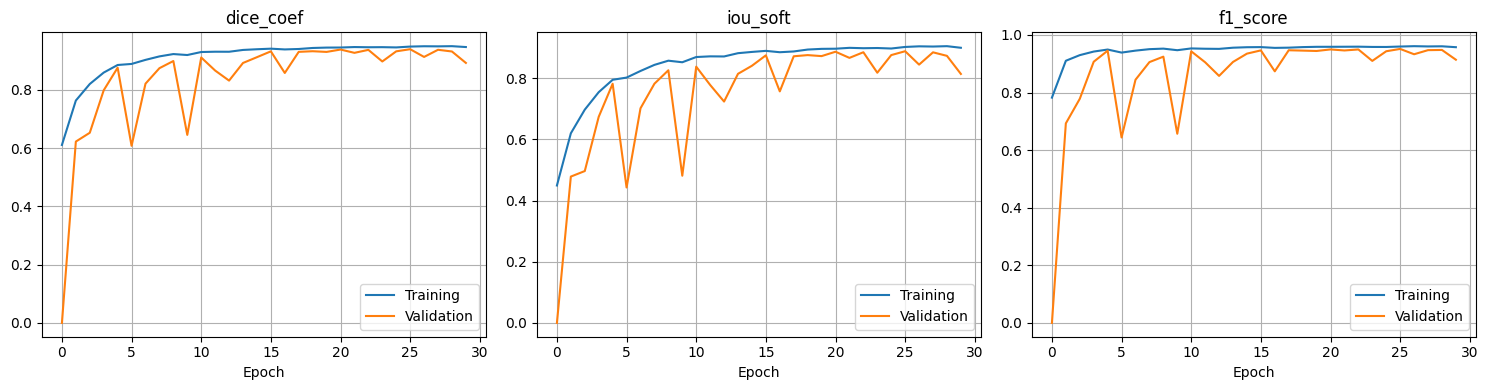

In [15]:
model_unet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=ut.bce_dice_loss,
    metrics=[
        ut.dice_coef,
        ut.iou_soft,
        ut.f1_score
    ]
)

training_history = model_unet.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=callbacks)
ut.plot_training_history(training_history, list_of_metrics=['dice_coef','iou_soft','f1_score'])



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


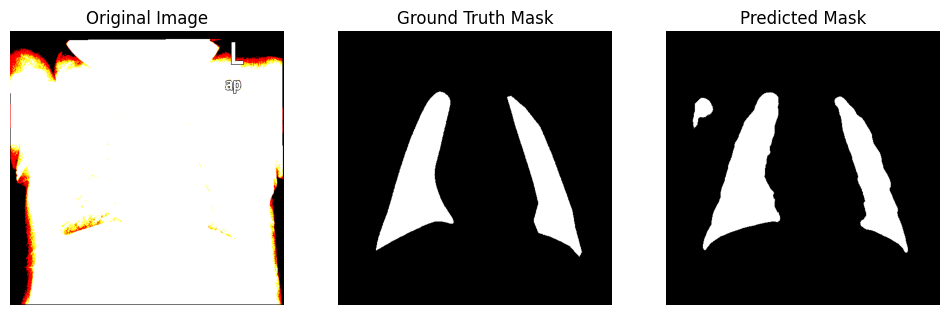

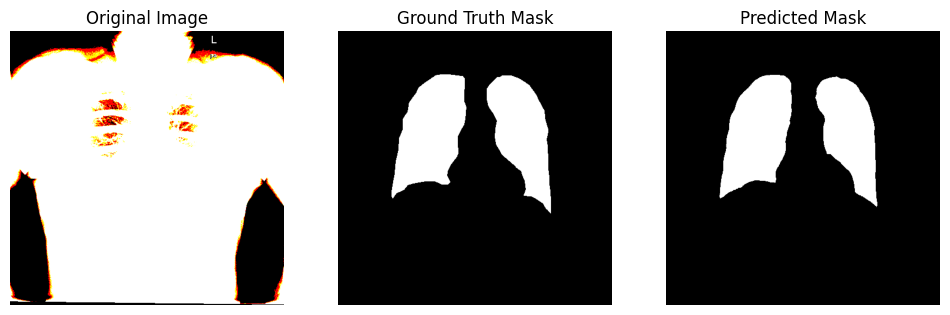

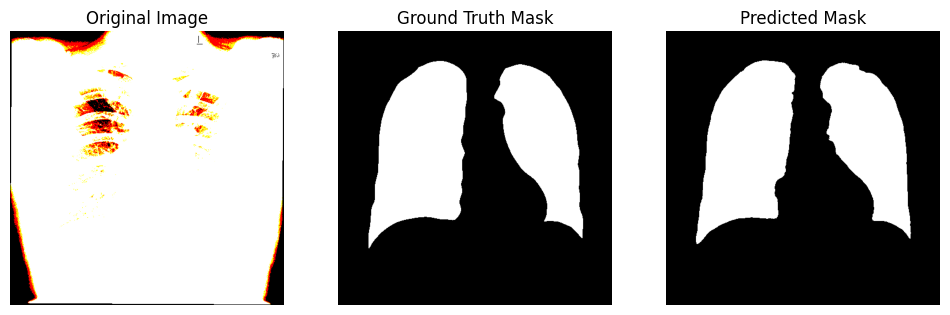

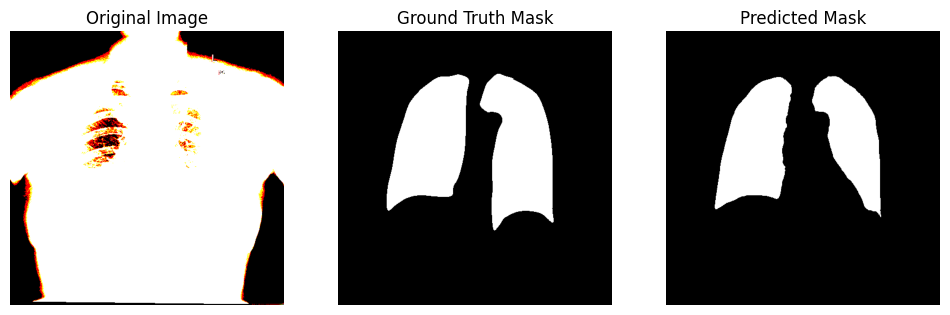

InvalidArgumentError: {{function_node __wrapped__StridedSlice_device_/job:localhost/replica:0/task:0/device:GPU:0}} slice index 4 of dimension 0 out of bounds. [Op:StridedSlice] name: strided_slice/

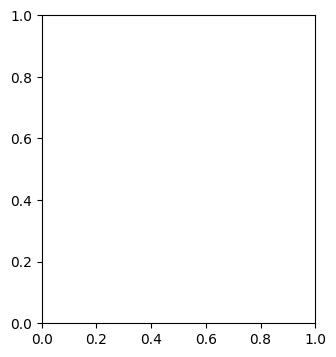

In [16]:
ut.visualize_predictions(model_unet, val_ds, n=5)


Hmm Im not sure why the original images got so weird.

alright I found out, its because in utilities, when preparing the data, we standardize it, so the values become closer to each other, so it seems that the image got ruined, but all that happened is that the contrast between pixels got lowered, cuz of stanrdadization.

In [17]:
from tensorflow.keras.applications import ResNet50


def get_unet_resnet50(input_shape=(256, 256, 3), n_classes=1, dropout=0.1, batchnorm=True):
    """U-Net with ResNet50 encoder (transfer learning)"""
    # --- Encoder (pretrained ResNet50) ---
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    # Extract skip connection layers
    skip1 = base_model.get_layer("conv1_relu").output       # 128x128
    skip2 = base_model.get_layer("conv2_block3_out").output # 64x64
    skip3 = base_model.get_layer("conv3_block4_out").output # 32x32
    skip4 = base_model.get_layer("conv4_block6_out").output # 16x16
    encoder_output = base_model.get_layer("conv5_block3_out").output  # 8x8

    # --- Decoder ---
    u6 = Conv2DTranspose(512, 3, strides=2, padding='same')(encoder_output)
    u6 = concatenate([u6, skip4])
    u6 = Dropout(dropout)(u6)
    c6 = conv2d_block(u6, 512, batchnorm=batchnorm)

    u7 = Conv2DTranspose(256, 3, strides=2, padding='same')(c6)
    u7 = concatenate([u7, skip3])
    u7 = Dropout(dropout)(u7)
    c7 = conv2d_block(u7, 256, batchnorm=batchnorm)

    u8 = Conv2DTranspose(128, 3, strides=2, padding='same')(c7)
    u8 = concatenate([u8, skip2])
    u8 = Dropout(dropout)(u8)
    c8 = conv2d_block(u8, 128, batchnorm=batchnorm)

    u9 = Conv2DTranspose(64, 3, strides=2, padding='same')(c8)
    u9 = concatenate([u9, skip1])
    u9 = Dropout(dropout)(u9)
    c9 = conv2d_block(u9, 64, batchnorm=batchnorm)

    u10 = Conv2DTranspose(32, 3, strides=2, padding='same')(c9)
    u10 = Dropout(0.1)(u10)
    c10 = conv2d_block(u10, 32, batchnorm=batchnorm)

    # --- Output head ---
    if n_classes == 1:
        outputs = Conv2D(1, (1, 1), activation='sigmoid')(c10)
    else:
        outputs = Conv2D(n_classes, (1, 1), activation='softmax')(c10)

    # --- Model ---
    return Model(inputs=base_model.input, outputs=outputs)


In [18]:
model_imagenet = get_unet_resnet50(input_shape=(512, 512, 3), dropout = 0.1, batchnorm = True, n_classes = 1)

model_imagenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=ut.bce_dice_loss,
    metrics=[
        ut.dice_coef,
        ut.iou_soft,
        ut.f1_score

    ]
)

In [19]:
history = model_imagenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - dice_coef: 0.6456 - f1_score: 0.7740 - iou_soft: 0.5045 - loss: 0.3374
Epoch 1: val_dice_coef did not improve from 0.93906
40/40 ━━━━━━━━━━━━━━━━━━━━ 175s 750ms/step - dice_coef: 0.6486 - f1_score: 0.7767 - iou_soft: 0.5078 - loss: 0.3343 - val_dice_coef: 0.1955 - val_f1_score: 0.2036 - val_iou_soft: 0.1110 - val_loss: 1136.4329
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - dice_coef: 0.8802 - f1_score: 0.9510 - iou_soft: 0.7880 - loss: 0.1051
Epoch 2: val_dice_coef did not improve from 0.93906
40/40 ━━━━━━━━━━━━━━━━━━━━ 49s 620ms/step - dice_coef: 0.8805 - f1_score: 0.9511 - iou_soft: 0.7884 - loss: 0.1049 - val_dice_coef: 0.2868 - val_f1_score: 0.3011 - val_iou_soft: 0.1748 - val_loss: 1.0227
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - dice_coef: 0.9091 - f1_score: 0.9584 - iou_soft: 0.8345 - loss: 0.0797
Epoch 3: val_dice_coef did not improve from 0.93906
40/40 ━━━━━━━━━━━━━━━━━━━━ 50s 653ms/step - dice_coef: 0.

40/40 ━━━━━━━━━━━━━━━━━━━━ 50s 674ms/step - dice_coef: 0.9449 - f1_score: 0.9630 - iou_soft: 0.8962 - loss: 0.0538 - val_dice_coef: 0.9452 - val_f1_score: 0.9549 - val_iou_soft: 0.8986 - val_loss: 0.0651
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - dice_coef: 0.9483 - f1_score: 0.9638 - iou_soft: 0.9023 - loss: 0.0514
Epoch 8: val_dice_coef did not improve from 0.94524
40/40 ━━━━━━━━━━━━━━━━━━━━ 49s 608ms/step - dice_coef: 0.9482 - f1_score: 0.9638 - iou_soft: 0.9022 - loss: 0.0515 - val_dice_coef: 0.9300 - val_f1_score: 0.9482 - val_iou_soft: 0.8728 - val_loss: 0.0701
Epoch 9/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - dice_coef: 0.9517 - f1_score: 0.9663 - iou_soft: 0.9086 - loss: 0.0474
Epoch 9: val_dice_coef did not improve from 0.94524
40/40 ━━━━━━━━━━━━━━━━━━━━ 49s 620ms/step - dice_coef: 0.9517 - f1_score: 0.9662 - iou_soft: 0.9085 - loss: 0.0474 - val_dice_coef: 0.9421 - val_f1_score: 0.9530 - val_iou_soft: 0.8939 - val_loss: 0.0647
Epoch 10/30
40/40 ━━━━━━━━━━━━━━━━

40/40 ━━━━━━━━━━━━━━━━━━━━ 54s 759ms/step - dice_coef: 0.9524 - f1_score: 0.9665 - iou_soft: 0.9097 - loss: 0.0471 - val_dice_coef: 0.9481 - val_f1_score: 0.9542 - val_iou_soft: 0.9023 - val_loss: 0.0645
Epoch 11/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - dice_coef: 0.9566 - f1_score: 0.9679 - iou_soft: 0.9174 - loss: 0.0445
Epoch 11: val_dice_coef did not improve from 0.94810
40/40 ━━━━━━━━━━━━━━━━━━━━ 47s 609ms/step - dice_coef: 0.9565 - f1_score: 0.9678 - iou_soft: 0.9173 - loss: 0.0446 - val_dice_coef: 0.8203 - val_f1_score: 0.8211 - val_iou_soft: 0.7003 - val_loss: 0.2483
Epoch 12/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - dice_coef: 0.9503 - f1_score: 0.9619 - iou_soft: 0.9062 - loss: 0.0514
Epoch 12: val_dice_coef did not improve from 0.94810
40/40 ━━━━━━━━━━━━━━━━━━━━ 49s 638ms/step - dice_coef: 0.9503 - f1_score: 0.9619 - iou_soft: 0.9063 - loss: 0.0513 - val_dice_coef: 0.8382 - val_f1_score: 0.8664 - val_iou_soft: 0.7366 - val_loss: 0.2118
Epoch 13/30
40/40 ━━━━━━━━━━━━

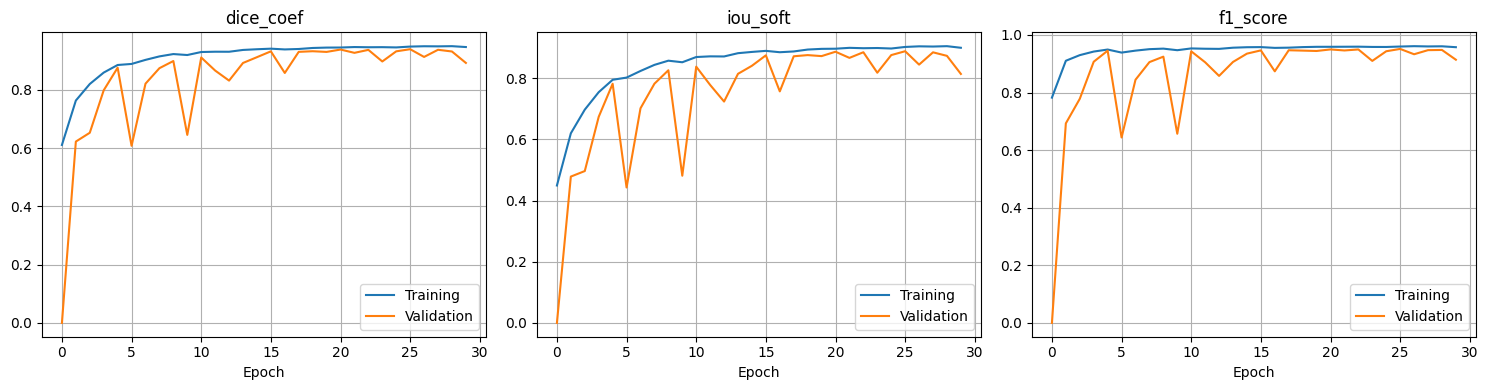

In [20]:
ut.plot_training_history(training_history, list_of_metrics=['dice_coef','iou_soft','f1_score'])

In [21]:
test_results_imagenet = model_imagenet.evaluate(test_ds, verbose=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - dice_coef: 0.9549 - f1_score: 0.9650 - iou_soft: 0.9142 - loss: 0.0453


In [22]:
test_results_unet = model_unet.evaluate(test_ds, verbose=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - dice_coef: 0.9445 - f1_score: 0.9577 - iou_soft: 0.8965 - loss: 0.0542


We see that both models did very well, however the U-Net using transfer learning did slightly better, which can be contributed to the imagenet network we started from.